In [ ]:
# Importar librerías
import pandas as pd
import numpy as np
from google.colab import drive
import os

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


#LECTURA DATA EMG y EEG

In [ ]:
import pandas as pd
import os

# Función para leer los archivos dentro de las carpetas de los sujetos y crear un DataFrame por archivo
def read_data_from_subject_folders(base_dir, signal_type):
    for subject_folder in os.listdir(base_dir):
        subject_path = os.path.join(base_dir, subject_folder)

        if os.path.isdir(subject_path):  # Verificar que sea un directorio
            for file_name in os.listdir(subject_path):
                if file_name.endswith('.csv'):
                    # Extraer información del nombre del archivo
                    parts = file_name.split('_')
                    subject_id = parts[0]  # Ejemplo: S1
                    repetition_id = parts[1]  # Ejemplo: R1
                    gesture_id = parts[2].split('.')[0]  # Ejemplo: G1

                    # Crear el nombre del DataFrame
                    var_name = f"{subject_id}_{repetition_id}_{gesture_id}_{signal_type}"

                    # Leer el archivo CSV
                    file_path = os.path.join(subject_path, file_name)
                    df = pd.read_csv(file_path)

                    # Asignar el DataFrame a una variable global
                    globals()[var_name] = df

# Rutas base de los datos EMG y EEG
emg_base_dir = '/content/drive/MyDrive/Biomecatronica/LAB5/EMG_DATA'
eeg_base_dir = '/content/drive/MyDrive/Biomecatronica/LAB5/EEG_DATA'

# Leer los datos EMG y EEG
read_data_from_subject_folders(emg_base_dir, 'EMG')
read_data_from_subject_folders(eeg_base_dir, 'EEG')

In [ ]:
S11_R5_G2_EEG

,Sensor1,Sensor2,Sensor3,Sensor4,Sensor5,Sensor6,Sensor7,Sensor8
0,50471.535381,4889.891134,-39303.508616,-38263.437243,-15080.274949,-31529.258970,-35680.179081,-25748.628467
1,50411.811520,4937.030964,-39163.720806,-38360.935552,-15063.935824,-31613.927378,-35653.513450,-25696.928882
2,50940.095000,4985.020159,-38902.048934,-37980.888841,-15120.753958,-31222.414222,-35690.036200,-25689.284586
3,51073.087880,4937.813275,-39004.509330,-37823.845485,-15147.106665,-31077.574918,-35727.296558,-25747.734397
4,50559.645958,4888.617085,-39280.374560,-38194.526815,-15088.835667,-31461.779053,-35693.880700,-25761.167796
...,...,...,...,...,...,...,...,...
1345,51148.010927,5004.130900,-38902.004230,-37852.500421,-15230.165747,-31070.869395,-35662.744720,-25763.939412
1346,51008.491338,4942.261272,-39126.795724,-37904.579986,-15217.425253,-31140.897410,-35672.959468,-25816.018977
1347,50479.582009,4911.304106,-39336.030404,-38308.006621,-15158.930738,-31551.208383,-35627.138391,-25809.581674
1348,50551.934606,4971.296188,-39138.664501,-38305.436171,-15158.438999,-31537.529115,-35607.312394,-25752.875299


#EDA

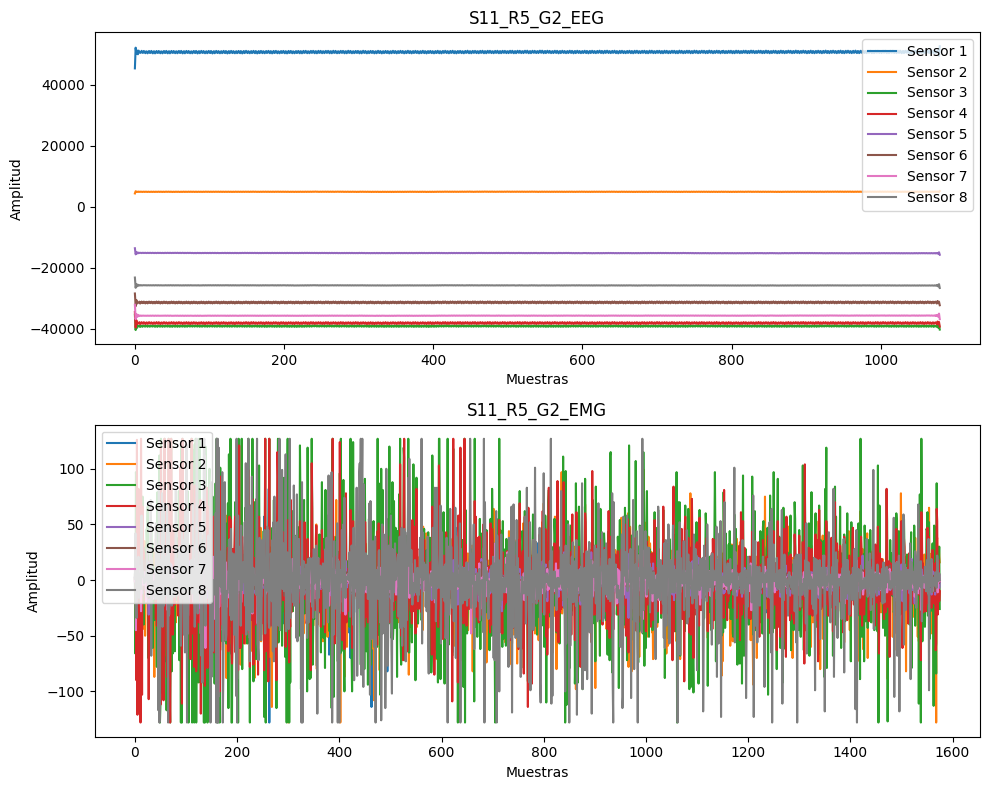

In [ ]:
import matplotlib.pyplot as plt

# Crear la figura y los subplots
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Graficar S11_R5_G2_EEG
for i in range(8):  # Asumiendo que hay 8 columnas de sensores
    axes[0].plot(S11_R5_G2_EEG.iloc[:, i], label=f'Sensor {i+1}')
axes[0].set_title('S11_R5_G2_EEG')
axes[0].set_xlabel('Muestras')
axes[0].set_ylabel('Amplitud')
axes[0].legend()

# Graficar S11_R5_G2_EMG
for i in range(8):  # Asumiendo que hay 8 columnas de sensores
    axes[1].plot(S11_R5_G2_EMG.iloc[:, i], label=f'Sensor {i+1}')
axes[1].set_title('S11_R5_G2_EMG')
axes[1].set_xlabel('Muestras')
axes[1].set_ylabel('Amplitud')
axes[1].legend()

# Ajustar el espaciado entre subplots
plt.tight_layout()

# Mostrar la gráfica
plt.show()

#Verificación de duplicados y valores NaN

In [ ]:
# Inicializar contadores globales
total_nan_count = 0
total_duplicate_count = 0

# Verificar duplicados y valores NaN en cada DataFrame
for var_name in list(globals().keys()):
    if var_name.endswith("_EMG") or var_name.endswith("_EEG"):
        df = globals()[var_name]  # Acceder al DataFrame

        # Contar valores NaN y duplicados en el DataFrame actual
        nan_count = df.isnull().sum().sum()  # Suma de valores NaN totales
        duplicate_count = df.duplicated().sum()  # Número de filas duplicadas

        # Acumular los totales
        total_nan_count += nan_count
        total_duplicate_count += duplicate_count

# Imprimir los totales acumulados
print(f"Total de valores NaN encontrados: {total_nan_count}")
print(f"Total de filas duplicadas encontradas: {total_duplicate_count}")

Total de valores NaN encontrados: 0
Total de filas duplicadas encontradas: 660


In [ ]:
# Proceso iterativo para eliminar filas duplicadas
for var_name in list(globals().keys()):
    if var_name.endswith("_EMG") or var_name.endswith("_EEG"):
        df = globals()[var_name]  # Acceder al DataFrame

        # Contar duplicados antes de eliminar
        initial_duplicates = df.duplicated().sum()

        # Eliminar filas duplicadas
        df = df.drop_duplicates()

        # Actualizar el DataFrame global
        globals()[var_name] = df

        # Imprimir resultados del proceso
        print(f"{var_name}: {initial_duplicates} filas duplicadas eliminadas.")


S10_R3_G5_EMG: 2 filas duplicadas eliminadas.
S10_R3_G2_EMG: 2 filas duplicadas eliminadas.
S10_R2_G1_EMG: 2 filas duplicadas eliminadas.
S10_R1_G6_EMG: 0 filas duplicadas eliminadas.
S10_R4_G1_EMG: 2 filas duplicadas eliminadas.
S10_R1_G5_EMG: 2 filas duplicadas eliminadas.
S10_R1_G1_EMG: 0 filas duplicadas eliminadas.
S10_R2_G5_EMG: 2 filas duplicadas eliminadas.
S10_R2_G6_EMG: 2 filas duplicadas eliminadas.
S10_R3_G6_EMG: 0 filas duplicadas eliminadas.
S10_R2_G2_EMG: 2 filas duplicadas eliminadas.
S10_R2_G7_EMG: 2 filas duplicadas eliminadas.
S10_R3_G3_EMG: 2 filas duplicadas eliminadas.
S10_R2_G4_EMG: 2 filas duplicadas eliminadas.
S10_R1_G7_EMG: 2 filas duplicadas eliminadas.
S10_R3_G4_EMG: 2 filas duplicadas eliminadas.
S10_R1_G2_EMG: 2 filas duplicadas eliminadas.
S10_R1_G3_EMG: 2 filas duplicadas eliminadas.
S10_R3_G7_EMG: 2 filas duplicadas eliminadas.
S10_R2_G3_EMG: 2 filas duplicadas eliminadas.
S10_R1_G4_EMG: 0 filas duplicadas eliminadas.
S10_R3_G1_EMG: 2 filas duplicadas 

#Resampling

In [ ]:
import pandas as pd
from scipy.signal import resample_poly

# Proceso iterativo para aplicar resampling a los DataFrames de EEG
for var_name in list(globals().keys()):
    if var_name.endswith("_EEG"):  # Filtrar solo DataFrames de EEG
        df = globals()[var_name]  # Acceder al DataFrame

        # Aplicar resampling fraccional usando resample_poly (4/5 para 250 Hz -> 200 Hz)
        eeg_resampled = df.apply(lambda x: resample_poly(x, 4, 5, axis=0))

        # Crear un nuevo DataFrame con los datos resampleados
        resampled_df = pd.DataFrame(eeg_resampled, columns=df.columns)

        # Actualizar el DataFrame global
        globals()[var_name] = resampled_df

        # Imprimir mensaje de confirmación
        print(f"{var_name}: Resampling completado. Nueva longitud: {len(resampled_df)} muestras.")


S3_R2_G5_EEG: Resampling completado. Nueva longitud: 1080 muestras.
S3_R3_G1_EEG: Resampling completado. Nueva longitud: 1080 muestras.
S3_R1_G1_EEG: Resampling completado. Nueva longitud: 1080 muestras.
S3_R4_G3_EEG: Resampling completado. Nueva longitud: 1080 muestras.
S3_R2_G3_EEG: Resampling completado. Nueva longitud: 1080 muestras.
S3_R3_G3_EEG: Resampling completado. Nueva longitud: 1080 muestras.
S3_R4_G2_EEG: Resampling completado. Nueva longitud: 1080 muestras.
S3_R3_G4_EEG: Resampling completado. Nueva longitud: 1080 muestras.
S3_R1_G7_EEG: Resampling completado. Nueva longitud: 1080 muestras.
S3_R3_G6_EEG: Resampling completado. Nueva longitud: 1080 muestras.
S3_R2_G7_EEG: Resampling completado. Nueva longitud: 1080 muestras.
S3_R2_G6_EEG: Resampling completado. Nueva longitud: 1080 muestras.
S3_R2_G2_EEG: Resampling completado. Nueva longitud: 1080 muestras.
S3_R3_G5_EEG: Resampling completado. Nueva longitud: 1080 muestras.
S3_R2_G4_EEG: Resampling completado. Nueva longi

#Juntar cada df por tipo de señal y  agregar IDs

In [ ]:
import pandas as pd

# Lista para almacenar los DataFrames de EMG
emg_data = []

# Proceso iterativo para concatenar las señales de EMG
for var_name in list(globals().keys()):
    if var_name.endswith("_EMG"):  # Filtrar solo DataFrames de EMG
        df = globals()[var_name]  # Acceder al DataFrame

        # Extraer IDs desde el nombre de la variable
        parts = var_name.split("_")
        sujeto = int(parts[0][1:])  # Ejemplo: S1 -> 1
        repeticion = int(parts[1][1:])  # Ejemplo: R1 -> 1
        gesto = int(parts[2][1:])  # Ejemplo: G1 -> 1

        # Agregar las columnas de ID al DataFrame
        df['Sujeto'] = sujeto
        df['Repeticion'] = repeticion
        df['Gesto'] = gesto
        df['TipoDeSenal'] = "EMG"

        # Agregar a la lista
        emg_data.append(df)

# Concatenar todos los DataFrames de EMG
final_emg_df = pd.concat(emg_data, ignore_index=True)

# Ordenar por Sujeto, Repeticion, Gesto y TipoDeSenal
final_emg_df = final_emg_df.sort_values(by=['Sujeto', 'Repeticion', 'Gesto', 'TipoDeSenal']).reset_index(drop=True)

In [ ]:
final_emg_df

,Channel_1,Channel_2,Channel_3,Channel_4,Channel_5,Channel_6,Channel_7,Channel_8,Sujeto,Repeticion,Gesto,TipoDeSenal
0,-4,-11,-39,-18,-1,1,-2,-1,1,1,1,EMG
1,2,12,5,9,1,0,-14,-20,1,1,1,EMG
2,29,27,24,19,-46,-14,-19,21,1,1,1,EMG
3,-33,-28,-9,44,63,13,19,15,1,1,1,EMG
4,39,-36,-50,22,8,0,-17,-3,1,1,1,EMG
...,...,...,...,...,...,...,...,...,...,...,...,...
664001,-2,-6,-23,-7,2,-1,-4,-1,11,6,7,EMG
664002,-5,-5,20,12,-3,-2,-3,-3,11,6,7,EMG
664003,-2,3,8,14,3,1,-2,2,11,6,7,EMG
664004,-2,1,-6,-16,-3,-4,-4,-1,11,6,7,EMG


In [ ]:
print("Unique values for Sujeto:")
print(final_emg_df['Sujeto'].unique())

print("\nUnique values for Repeticion:")
print(final_emg_df['Repeticion'].unique())

print("\nUnique values for Gesto:")
print(final_emg_df['Gesto'].unique())

Unique values for Sujeto:
[ 1  2  3  4  5  7  8  9 10 11]

Unique values for Repeticion:
[1 2 3 4 5 6]

Unique values for Gesto:
[1 2 3 4 5 6 7]


In [ ]:
# Lista para almacenar los DataFrames de EEG
eeg_data = []

# Proceso iterativo para concatenar las señales de EEG
for var_name in list(globals().keys()):
    if var_name.endswith("_EEG"):  # Filtrar solo DataFrames de EEG
        df = globals()[var_name]  # Acceder al DataFrame

        # Extraer IDs desde el nombre de la variable
        parts = var_name.split("_")
        sujeto = int(parts[0][1:])  # Ejemplo: S1 -> 1
        repeticion = int(parts[1][1:])  # Ejemplo: R1 -> 1
        gesto = int(parts[2][1:])  # Ejemplo: G1 -> 1

        # Agregar las columnas de ID al DataFrame
        df['Sujeto'] = sujeto
        df['Repeticion'] = repeticion
        df['Gesto'] = gesto
        df['TipoDeSenal'] = "EEG"

        # Agregar a la lista
        eeg_data.append(df)

# Concatenar todos los DataFrames de EEG
final_eeg_df = pd.concat(eeg_data, ignore_index=True)

# Ordenar por Sujeto, Repeticion, Gesto y TipoDeSenal
final_eeg_df = final_eeg_df.sort_values(by=['Sujeto', 'Repeticion', 'Gesto', 'TipoDeSenal']).reset_index(drop=True)

In [ ]:
final_eeg_df

,Sensor1,Sensor2,Sensor3,Sensor4,Sensor5,Sensor6,Sensor7,Sensor8,Sujeto,Repeticion,Gesto,TipoDeSenal
0,10621.493930,23215.555738,7240.736090,-9587.378186,-31940.405708,3106.748032,24207.304910,8535.838984,1,1,1,EEG
1,12426.042948,26852.140584,9684.406749,-10796.514893,-36798.741760,3544.686662,27674.598427,9728.213598,1,1,1,EEG
2,11929.040326,28657.553339,12242.452584,-10378.586033,-35304.817979,3148.627521,26054.207346,9018.386594,1,1,1,EEG
3,11972.602455,27492.275526,9425.038792,-10824.383453,-36003.676568,3386.769011,27070.853791,9478.296471,1,1,1,EEG
4,11864.791627,25041.675941,8164.716995,-10412.684809,-35260.840842,3475.414384,26720.095083,9443.777798,1,1,1,EEG
...,...,...,...,...,...,...,...,...,...,...,...,...
451943,51290.150535,9801.028553,-33090.686962,-32383.100554,-21987.335163,-27568.712185,-28529.510420,-23862.522726,11,6,7,EEG
451944,50176.802976,9614.669106,-33019.783869,-32427.123507,-21699.602579,-27680.595353,-28183.368978,-23656.439514,11,6,7,EEG
451945,51216.630970,9852.665949,-33367.393355,-32974.369928,-22075.992281,-28117.145408,-28662.541171,-23994.128249,11,6,7,EEG
451946,50262.039528,9612.972537,-32276.765033,-31654.062237,-21513.990054,-26930.681592,-27903.817540,-23312.638798,11,6,7,EEG


In [ ]:
print("Unique values for Sujeto:")
print(final_eeg_df['Sujeto'].unique())

print("\nUnique values for Repeticion:")
print(final_eeg_df['Repeticion'].unique())

print("\nUnique values for Gesto:")
print(final_eeg_df['Gesto'].unique())

Unique values for Sujeto:
[ 1  2  3  4  5  6  8  9 10 11]

Unique values for Repeticion:
[1 2 3 4 5 6]

Unique values for Gesto:
[1 2 3 4 5 6 7]


In [ ]:
# Eliminar la muestra específica del DataFrame EEG
final_eeg_df = final_eeg_df[~((final_eeg_df['Sujeto'] == 11) &
                              (final_eeg_df['Repeticion'] == 6) &
                              (final_eeg_df['Gesto'] == 2))]
# Eliminar todas las filas correspondientes al sujeto 7 en EMG
final_emg_df = final_emg_df[final_emg_df['Sujeto'] != 7]
# Eliminar todas las filas correspondientes al sujeto 6 en EEG
final_eeg_df = final_eeg_df[final_eeg_df['Sujeto'] != 6]

#Concatenacion

In [ ]:
import pandas as pd

# Renombrar las columnas de sensores en EMG para que coincidan con el formato de EEG
final_emg_df.columns = [f"Sensor{i}" if col.startswith("Channel_") else col for i, col in enumerate(final_emg_df.columns, start=1)]

# Lista para almacenar los DataFrames combinados por sujeto, gesto y repetición
combined_data = []

# Obtener las combinaciones únicas de Sujeto, Gesto y Repetición presentes en ambos DataFrames
combinations_emg = set(zip(final_emg_df['Sujeto'], final_emg_df['Gesto'], final_emg_df['Repeticion']))
combinations_eeg = set(zip(final_eeg_df['Sujeto'], final_eeg_df['Gesto'], final_eeg_df['Repeticion']))
common_combinations = combinations_emg.intersection(combinations_eeg)

# Iterar sobre cada combinación de Sujeto, Gesto y Repetición
for sujeto, gesto, repeticion in common_combinations:
    # Filtrar las filas correspondientes para cada combinación en EMG y EEG
    emg_df = final_emg_df[(final_emg_df['Sujeto'] == sujeto) &
                          (final_emg_df['Gesto'] == gesto) &
                          (final_emg_df['Repeticion'] == repeticion)]
    eeg_df = final_eeg_df[(final_eeg_df['Sujeto'] == sujeto) &
                          (final_eeg_df['Gesto'] == gesto) &
                          (final_eeg_df['Repeticion'] == repeticion)]

    # Excluir las columnas de IDs (Sujeto, Gesto, Repetición, TipoDeSenal) de las señales
    emg_signals = emg_df.iloc[:, :-4].reset_index(drop=True)  # Excluir las últimas 4 columnas (IDs)
    eeg_signals = eeg_df.iloc[:, :-4].reset_index(drop=True)  # Excluir las últimas 4 columnas (IDs)

    # Alinear el tamaño de las señales
    min_length = min(len(emg_signals), len(eeg_signals))
    emg_signals_truncated = emg_signals.iloc[:min_length, :].reset_index(drop=True)
    eeg_signals_truncated = eeg_signals.iloc[:min_length, :].reset_index(drop=True)

    # Renombrar las columnas de EMG y EEG para diferenciarlas
    emg_signals_truncated.columns = [f"Sensor{i+1}_EMG" for i in range(emg_signals_truncated.shape[1])]
    eeg_signals_truncated.columns = [f"Sensor{i+1}_EEG" for i in range(eeg_signals_truncated.shape[1])]

    # Concatenar las señales de EMG y EEG columna a columna
    merged_signals = pd.concat([emg_signals_truncated, eeg_signals_truncated], axis=1)

    # Agregar las columnas de IDs (Sujeto, Gesto, Repetición, TipoDeSenal) al principio del DataFrame combinado
    merged_signals.insert(0, 'Repeticion', repeticion)
    merged_signals.insert(0, 'Gesto', gesto)
    merged_signals.insert(0, 'Sujeto', sujeto)

    # Agregar el DataFrame combinado a la lista
    combined_data.append(merged_signals)

# Concatenar todos los DataFrames combinados
final_combined_df = pd.concat(combined_data, ignore_index=True)

# Ordenar el DataFrame final por Sujeto, Gesto y Repetición
final_combined_df = final_combined_df.sort_values(by=['Sujeto', 'Gesto', 'Repeticion']).reset_index(drop=True)

In [ ]:
final_combined_df

,Sujeto,Gesto,Repeticion,Sensor1_EMG,Sensor2_EMG,Sensor3_EMG,Sensor4_EMG,Sensor5_EMG,Sensor6_EMG,Sensor7_EMG,Sensor8_EMG,Sensor1_EEG,Sensor2_EEG,Sensor3_EEG,Sensor4_EEG,Sensor5_EEG,Sensor6_EEG,Sensor7_EEG,Sensor8_EEG
0,1,1,1,-4,-11,-39,-18,-1,1,-2,-1,10621.493930,23215.555738,7240.736090,-9587.378186,-31940.405708,3106.748032,24207.304910,8535.838984
1,1,1,1,2,12,5,9,1,0,-14,-20,12426.042948,26852.140584,9684.406749,-10796.514893,-36798.741760,3544.686662,27674.598427,9728.213598
2,1,1,1,29,27,24,19,-46,-14,-19,21,11929.040326,28657.553339,12242.452584,-10378.586033,-35304.817979,3148.627521,26054.207346,9018.386594
3,1,1,1,-33,-28,-9,44,63,13,19,15,11972.602455,27492.275526,9425.038792,-10824.383453,-36003.676568,3386.769011,27070.853791,9478.296471
4,1,1,1,39,-36,-50,22,8,0,-17,-3,11864.791627,25041.675941,8164.716995,-10412.684809,-35260.840842,3475.414384,26720.095083,9443.777798
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406582,11,7,6,0,4,16,9,-1,0,-4,-1,51290.150535,9801.028553,-33090.686962,-32383.100554,-21987.335163,-27568.712185,-28529.510420,-23862.522726
406583,11,7,6,-1,-6,6,-5,0,-2,-5,-3,50176.802976,9614.669106,-33019.783869,-32427.123507,-21699.602579,-27680.595353,-28183.368978,-23656.439514
406584,11,7,6,0,-4,0,8,1,1,-1,0,51216.630970,9852.665949,-33367.393355,-32974.369928,-22075.992281,-28117.145408,-28662.541171,-23994.128249
406585,11,7,6,-3,0,-2,10,-2,-5,-6,-3,50262.039528,9612.972537,-32276.765033,-31654.062237,-21513.990054,-26930.681592,-27903.817540,-23312.638798


In [ ]:
import numpy as np
from scipy.signal import butter, filtfilt

# Función para aplicar un filtro pasa banda
def bandpass_filter(data, lowcut, highcut, fs, order=5):
    nyquist = 0.5 * fs  # Frecuencia de Nyquist
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')  # Coeficientes del filtro
    y = filtfilt(b, a, data)  # Aplicar el filtro
    return y

# Parámetros del filtro para EEG (1-50 Hz)
fs_eeg = 200.0  # Frecuencia de muestreo ajustada
lowcut_eeg = 1.0
highcut_eeg = 49.0

# Parámetros del filtro para EMG (10-100 Hz)
fs_emg = 200.0  # Frecuencia de muestreo (igualada a 200 Hz)
lowcut_emg = 10.0
highcut_emg = 99.0

# Crear un nuevo DataFrame para almacenar las señales filtradas
filtered_combined_df = final_combined_df.copy()

# Aplicar los filtros de manera iterativa a las columnas de sensores
for column in filtered_combined_df.columns:
    if column.endswith("_EMG"):  # Filtrar las columnas de EMG
        filtered_combined_df[column] = bandpass_filter(
            filtered_combined_df[column].values, lowcut_emg, highcut_emg, fs_emg
        )
        print(f"{column}: Filtro pasa banda (10-100 Hz) aplicado.")
    elif column.endswith("_EEG"):  # Filtrar las columnas de EEG
        filtered_combined_df[column] = bandpass_filter(
            filtered_combined_df[column].values, lowcut_eeg, highcut_eeg, fs_eeg
        )
        print(f"{column}: Filtro pasa banda (1-50 Hz) aplicado.")

Sensor1_EMG: Filtro pasa banda (10-100 Hz) aplicado.
Sensor2_EMG: Filtro pasa banda (10-100 Hz) aplicado.
Sensor3_EMG: Filtro pasa banda (10-100 Hz) aplicado.
Sensor4_EMG: Filtro pasa banda (10-100 Hz) aplicado.
Sensor5_EMG: Filtro pasa banda (10-100 Hz) aplicado.
Sensor6_EMG: Filtro pasa banda (10-100 Hz) aplicado.
Sensor7_EMG: Filtro pasa banda (10-100 Hz) aplicado.
Sensor8_EMG: Filtro pasa banda (10-100 Hz) aplicado.
Sensor1_EEG: Filtro pasa banda (1-50 Hz) aplicado.
Sensor2_EEG: Filtro pasa banda (1-50 Hz) aplicado.
Sensor3_EEG: Filtro pasa banda (1-50 Hz) aplicado.
Sensor4_EEG: Filtro pasa banda (1-50 Hz) aplicado.
Sensor5_EEG: Filtro pasa banda (1-50 Hz) aplicado.
Sensor6_EEG: Filtro pasa banda (1-50 Hz) aplicado.
Sensor7_EEG: Filtro pasa banda (1-50 Hz) aplicado.
Sensor8_EEG: Filtro pasa banda (1-50 Hz) aplicado.


In [ ]:
filtered_combined_df

,Sujeto,Gesto,Repeticion,Sensor1_EMG,Sensor2_EMG,Sensor3_EMG,Sensor4_EMG,Sensor5_EMG,Sensor6_EMG,Sensor7_EMG,Sensor8_EMG,Sensor1_EEG,Sensor2_EEG,Sensor3_EEG,Sensor4_EEG,Sensor5_EEG,Sensor6_EEG,Sensor7_EEG,Sensor8_EEG
0,1,1,1,2.469442,-1.763526,-0.709053,-2.496313,1.099652,0.467385,0.902164,-1.083253,-23.707427,64.828593,-83.771410,-27.292428,8.062463,-2.563803,5.888061,2.292340
1,1,1,1,0.939071,23.217573,37.562225,26.433919,0.301660,-0.899381,-13.079334,-18.804945,1232.770788,3889.786132,2984.568078,-865.799231,-3357.149153,184.103890,2172.660589,679.176021
2,1,1,1,31.290810,32.879164,45.656936,27.495503,-44.837727,-12.976958,-15.388525,21.109587,1587.538235,4864.329207,3519.021988,-1155.416035,-4376.318226,263.136860,2897.456607,922.120274
3,1,1,1,-38.038868,-19.809557,7.735800,55.795626,61.546609,13.574782,20.544307,16.422757,1289.419027,3774.518658,2441.058629,-990.146090,-3618.005208,247.286685,2478.773419,811.027214
4,1,1,1,38.084255,-32.882672,-42.489879,24.316003,8.289726,2.369986,-12.653627,-2.489584,1109.411029,3198.568046,2083.230958,-837.591813,-3086.633363,214.008994,2117.576600,697.466880
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406582,11,7,6,2.982033,3.686286,20.465029,18.023946,-0.808490,1.327755,-2.411316,0.134496,-1400.520356,-245.894829,1083.455785,965.920984,639.419632,832.238600,831.568531,728.547122
406583,11,7,6,0.165476,-6.073792,15.870031,9.067414,0.075595,-0.588180,-3.437858,-1.413073,-1683.802633,-297.890863,1275.303835,1142.417523,760.823792,981.899206,991.592677,866.270078
406584,11,7,6,2.122231,-4.874098,11.669295,29.383456,0.612645,2.170789,0.243129,1.457518,-2036.957605,-357.622090,1606.497803,1408.823964,933.725464,1220.172387,1220.331125,1077.726881
406585,11,7,6,-2.400162,-0.624239,15.610617,37.471855,-2.564726,-3.756988,-4.789584,-1.055886,-1610.335928,-279.503435,1327.091158,1146.723207,750.556042,999.292751,984.055071,878.176631


In [ ]:
import pandas as pd
from scipy.signal import welch
import numpy as np

# Definir las bandas de frecuencia para EEG
frequency_bands = {
    'Delta': (0.5, 4),
    'Theta': (4, 8),
    'Alpha': (8, 12),
    'Beta': (12, 30),
    'Gamma': (30, 50)
}

# Función para calcular potencia en bandas de frecuencia
def bandpower(data, fs, band):
    f, Pxx = welch(data, fs=fs)
    band_power = np.sum(Pxx[(f >= band[0]) & (f <= band[1])])
    return band_power

# Funciones para calcular características de tiempo (EMG)
def calculate_mav(data):
    return np.mean(np.abs(data))

def calculate_rms(data):
    return np.sqrt(np.mean(np.square(data)))

def calculate_wl(data):
    diff = np.diff(data, prepend=0)
    return np.sum(np.abs(diff))

def calculate_stddev(data):
    return np.std(data)

# Crear una lista para almacenar las características extraídas de todos los grupos
all_features = []

# Agrupar el DataFrame por Sujeto, Gesto y Repetición
grouped = filtered_combined_df.groupby(['Sujeto', 'Gesto', 'Repeticion'])

# Iterar sobre cada grupo
for (sujeto, gesto, repeticion), group in grouped:
    features = {'Sujeto': sujeto, 'Gesto': gesto, 'Repeticion': repeticion}

    # Extraer características para cada columna
    for column in group.columns:
        if column.startswith("Sensor") and column.endswith("_EEG"):
            # Extraer características para EEG
            for band_name, band_range in frequency_bands.items():
                feature_name = f"{column}_{band_name}Power"
                features[feature_name] = bandpower(group[column].values, fs=200, band=band_range)
        elif column.startswith("Sensor") and column.endswith("_EMG"):
            # Extraer características para EMG
            features[f"{column}_MAV"] = calculate_mav(group[column].values)
            features[f"{column}_RMS"] = calculate_rms(group[column].values)
            features[f"{column}_WL"] = calculate_wl(group[column].values)
            features[f"{column}_StdDev"] = calculate_stddev(group[column].values)

    # Agregar las características de este grupo a la lista
    all_features.append(features)

# Convertir la lista de características a un DataFrame
features_df = pd.DataFrame(all_features)

# Reordenar las columnas
column_order = ['Sujeto', 'Gesto', 'Repeticion'] + [col for col in features_df.columns if col not in ['Sujeto', 'Gesto', 'Repeticion']]
features_df = features_df[column_order]

# Mostrar las primeras filas del DataFrame final
print(features_df.head())

   Sujeto  Gesto  Repeticion  Sensor1_EMG_MAV  Sensor1_EMG_RMS  \
0       1      1           1        24.737071        34.887807   
1       1      1           2        20.205503        27.611025   
2       1      1           3        25.083003        35.232255   
3       1      1           4        21.009178        29.723699   
4       1      1           5        17.145244        24.465280   

   Sensor1_EMG_WL  Sensor1_EMG_StdDev  Sensor2_EMG_MAV  Sensor2_EMG_RMS  \
0    40929.300821           34.887791        23.109829        31.495048   
1    31840.924572           27.611020        21.615920        28.871055   
2    39852.363636           35.232236        23.568149        31.709058   
3    34446.343927           29.723697        24.337482        32.493303   
4    28741.600306           24.465278        17.390344        23.699375   

   Sensor2_EMG_WL  ...  Sensor7_EEG_DeltaPower  Sensor7_EEG_ThetaPower  \
0    37028.413881  ...            21595.792214               15.786983   
1   

In [ ]:
features_df

,Sujeto,Gesto,Repeticion,Sensor1_EMG_MAV,Sensor1_EMG_RMS,Sensor1_EMG_WL,Sensor1_EMG_StdDev,Sensor2_EMG_MAV,Sensor2_EMG_RMS,Sensor2_EMG_WL,...,Sensor7_EEG_DeltaPower,Sensor7_EEG_ThetaPower,Sensor7_EEG_AlphaPower,Sensor7_EEG_BetaPower,Sensor7_EEG_GammaPower,Sensor8_EEG_DeltaPower,Sensor8_EEG_ThetaPower,Sensor8_EEG_AlphaPower,Sensor8_EEG_BetaPower,Sensor8_EEG_GammaPower
0,1,1,1,24.737071,34.887807,40929.300821,34.887791,23.109829,31.495048,37028.413881,...,21595.792214,15.786983,39.345305,23.246444,15.831400,2398.408681,16.178198,39.399114,29.344284,10.700041
1,1,1,2,20.205503,27.611025,31840.924572,27.611020,21.615920,28.871055,34563.124458,...,342.149826,9.570087,53.217307,30.178995,27.665200,106.964824,10.293615,58.296720,30.427774,17.145230
2,1,1,3,25.083003,35.232255,39852.363636,35.232236,23.568149,31.709058,37283.703095,...,387.745298,23.991441,40.941521,30.270272,12.905904,79.638156,14.169581,47.642926,34.427374,8.117780
3,1,1,4,21.009178,29.723699,34446.343927,29.723697,24.337482,32.493303,39065.022013,...,364.448070,15.207609,45.556780,19.556109,11.705494,187.459026,14.193134,42.688366,25.455550,5.973474
4,1,1,5,17.145244,24.465280,28741.600306,24.465278,17.390344,23.699375,28130.523768,...,720.680472,27.636783,37.734565,36.373197,19.472682,1142.687616,51.167025,34.538681,41.884542,13.068180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372,11,7,2,6.989697,13.374347,12870.053032,13.374344,4.309437,7.108546,7216.892961,...,125.365521,12.869997,14.757947,21.249952,11.551987,88.628800,10.586579,18.663858,20.631528,9.681225
373,11,7,3,8.474143,15.218096,15406.935806,15.218086,3.539781,5.279266,5822.295618,...,37.583593,10.996838,12.786815,20.541519,10.725788,59.561802,8.886945,21.179678,20.893974,8.351825
374,11,7,4,9.705965,17.198868,17522.467991,17.198865,3.707411,5.464920,6294.502163,...,77.030604,10.310346,8.900628,12.444820,11.029624,76.954320,14.905001,8.571126,15.288445,9.341000
375,11,7,5,11.956471,19.322010,21757.878472,19.321995,4.808247,7.608809,7918.206504,...,39.441274,11.760410,13.593846,13.470832,11.223549,34.237008,14.671872,15.514090,13.147631,8.927632


In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
import pandas as pd

# Supongamos que features_df es tu DataFrame final con las características extraídas

# Separar las columnas de identificadores y características
id_columns = ['Sujeto', 'Gesto', 'Repeticion']
feature_columns = [col for col in features_df.columns if col not in id_columns]

# Crear DataFrames independientes para cada tipo de escalado
# 1. Escalado Z-score (StandardScaler)
scaler_standard = StandardScaler()
standard_scaled_features = scaler_standard.fit_transform(features_df[feature_columns])
standard_scaled_df = pd.DataFrame(standard_scaled_features, columns=feature_columns)
standard_scaled_df[id_columns] = features_df[id_columns]

# 2. Normalización Min-Max (MinMaxScaler)
scaler_minmax = MinMaxScaler()
minmax_scaled_features = scaler_minmax.fit_transform(features_df[feature_columns])
minmax_scaled_df = pd.DataFrame(minmax_scaled_features, columns=feature_columns)
minmax_scaled_df[id_columns] = features_df[id_columns]

# 3. Escalado robusto (RobustScaler)
scaler_robust = RobustScaler()
robust_scaled_features = scaler_robust.fit_transform(features_df[feature_columns])
robust_scaled_df = pd.DataFrame(robust_scaled_features, columns=feature_columns)
robust_scaled_df[id_columns] = features_df[id_columns]

# Reordenar las columnas para mantener los identificadores al inicio
standard_scaled_df = standard_scaled_df[id_columns + feature_columns]
minmax_scaled_df = minmax_scaled_df[id_columns + feature_columns]
robust_scaled_df = robust_scaled_df[id_columns + feature_columns]

# Imprimir los primeros registros de cada DataFrame
print("StandardScaler (Z-Score):")
print(standard_scaled_df.head())

print("\nMinMaxScaler (0-1):")
print(minmax_scaled_df.head())

print("\nRobustScaler (Mediana y Cuartiles):")
print(robust_scaled_df.head())


StandardScaler (Z-Score):
   Sujeto  Gesto  Repeticion  Sensor1_EMG_MAV  Sensor1_EMG_RMS  \
0       1      1           1         1.798877         1.875558   
1       1      1           2         1.262776         1.241925   
2       1      1           3         1.839802         1.905551   
3       1      1           4         1.357854         1.425888   
4       1      1           5         0.900736         0.968005   

   Sensor1_EMG_WL  Sensor1_EMG_StdDev  Sensor2_EMG_MAV  Sensor2_EMG_RMS  \
0        1.931859            1.875558         1.501446         1.498450   
1        1.249413            1.241925         1.321771         1.265895   
2        1.850992            1.905551         1.556569         1.517417   
3        1.445054            1.425889         1.649098         1.586922   
4        1.016684            0.968006         0.813553         0.807548   

   Sensor2_EMG_WL  ...  Sensor7_EEG_DeltaPower  Sensor7_EEG_ThetaPower  \
0        1.432739  ...               -0.037600      

In [ ]:
print(standard_scaled_df)

,Sujeto,Gesto,Repeticion,Sensor1_EMG_MAV,Sensor1_EMG_RMS,Sensor1_EMG_WL,Sensor1_EMG_StdDev,Sensor2_EMG_MAV,Sensor2_EMG_RMS,Sensor2_EMG_WL,...,Sensor7_EEG_DeltaPower,Sensor7_EEG_ThetaPower,Sensor7_EEG_AlphaPower,Sensor7_EEG_BetaPower,Sensor7_EEG_GammaPower,Sensor8_EEG_DeltaPower,Sensor8_EEG_ThetaPower,Sensor8_EEG_AlphaPower,Sensor8_EEG_BetaPower,Sensor8_EEG_GammaPower
0,1,1,1,1.798877,1.875558,1.931859,1.875558,1.501446,1.498450,1.432739,...,-0.037600,-0.449402,0.238227,-0.452761,-0.356670,-0.083537,-0.232976,-0.046155,-0.171978,-0.244119
1,1,1,2,1.262776,1.241925,1.249413,1.241925,1.321771,1.265895,1.253171,...,-0.126828,-0.574662,0.800580,-0.272719,0.002228,-0.092993,-0.294197,0.422945,-0.153648,-0.171805
2,1,1,3,1.839802,1.905551,1.850992,1.905551,1.556569,1.517417,1.451334,...,-0.126636,-0.284095,0.302935,-0.270348,-0.445395,-0.093106,-0.253873,0.158483,-0.085987,-0.273091
3,1,1,4,1.357854,1.425888,1.445054,1.425889,1.649098,1.586922,1.581083,...,-0.126734,-0.461075,0.490032,-0.548601,-0.481802,-0.092661,-0.253628,0.035495,-0.237763,-0.297150
4,1,1,5,0.900736,0.968005,1.016684,0.968006,0.813553,0.807548,0.784629,...,-0.125238,-0.210647,0.172929,-0.111852,-0.246236,-0.088719,0.131039,-0.166806,0.040165,-0.217549
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372,11,7,2,-0.300701,0.002250,-0.175110,0.002251,-0.759712,-0.662837,-0.738691,...,-0.127738,-0.508174,-0.758513,-0.504611,-0.486457,-0.093069,-0.291149,-0.560870,-0.319371,-0.255550
373,11,7,3,-0.125086,0.162797,0.015385,0.162797,-0.852280,-0.824959,-0.840272,...,-0.128106,-0.545915,-0.838421,-0.523009,-0.511514,-0.093189,-0.308832,-0.498420,-0.314931,-0.270465
374,11,7,4,0.020643,0.335275,0.174240,0.335275,-0.832119,-0.808505,-0.805877,...,-0.127941,-0.559747,-0.995962,-0.733285,-0.502300,-0.093117,-0.246222,-0.811405,-0.409759,-0.259367
375,11,7,5,0.286886,0.520150,0.492277,0.520149,-0.699719,-0.618500,-0.687609,...,-0.128098,-0.530531,-0.805705,-0.706639,-0.496418,-0.093293,-0.248647,-0.639058,-0.445975,-0.264005


In [ ]:
from sklearn.decomposition import PCA
import pandas as pd

# Mantener las columnas de ID (Sujeto, Gesto, Repeticion)
ids = standard_scaled_df[['Sujeto', 'Gesto', 'Repeticion']]

# Aplica PCA con 10 componentes, excluyendo las columnas de identificación
pca = PCA(n_components=15)
pca_features = pca.fit_transform(standard_scaled_df.drop(columns=['Sujeto', 'Gesto', 'Repeticion']))

# Crea un DataFrame con los componentes principales
df_pca = pd.DataFrame(pca_features, columns=[f'PCA{i+1}' for i in range(15)])

# Concatenar los IDs con los componentes principales
df_pca = pd.concat([ids, df_pca], axis=1)

# Muestra el DataFrame resultante
df_pca


,Sujeto,Gesto,Repeticion,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7,PCA8,PCA9,PCA10,PCA11,PCA12,PCA13,PCA14,PCA15
0,1,1,1,5.382979,-0.887651,-1.895589,2.522647,-0.047302,-0.835337,-0.413118,0.394906,-0.749052,0.028889,1.040121,1.338308,-0.462216,-0.824817,1.495408
1,1,1,2,4.422363,-0.444424,-1.569627,1.427888,0.683785,-1.147719,-0.144406,0.615533,-0.388446,0.408298,1.058844,1.853124,-0.344924,-0.454695,1.593814
2,1,1,3,5.595093,-0.816053,-1.877989,2.373697,0.136013,-0.760570,-0.556850,-0.237763,-0.436042,0.095573,1.178160,1.544909,-0.470156,-0.837023,0.960234
3,1,1,4,5.254034,-0.954975,-1.932891,1.941127,0.460906,-0.732046,-0.475741,-1.061032,-0.499943,-0.288301,1.183911,2.127500,-0.775269,-0.694248,0.112898
4,1,1,5,3.635006,0.851457,0.603342,2.312124,14.454821,6.745877,-7.050077,2.554421,-3.901382,-6.292287,-3.243077,-6.499905,-6.639691,-10.408006,-2.356327
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372,11,7,2,-3.635797,-0.790193,-0.205084,0.181219,-0.451605,0.318838,-0.273833,0.355851,-0.973548,0.108980,0.088737,-0.166126,-0.307999,-0.182964,1.217839
373,11,7,3,-3.247290,-0.861270,-0.358139,0.037940,-0.408460,0.307796,-0.159029,0.241699,-0.907934,0.248078,0.008342,-0.359328,-0.276087,-0.252692,1.386599
374,11,7,4,-3.542068,-0.917586,-0.354730,0.401480,-0.523951,0.475495,-0.339752,0.291381,-1.049699,0.489156,0.059282,-0.447328,-0.415606,-0.186933,1.670321
375,11,7,5,-3.072786,-0.884920,-0.421614,0.698381,-0.382877,0.528463,-0.480105,-0.252976,-0.952746,0.590386,0.333279,-0.206145,-0.470949,-0.292304,1.538889



Entrenando modelo: Random Forest


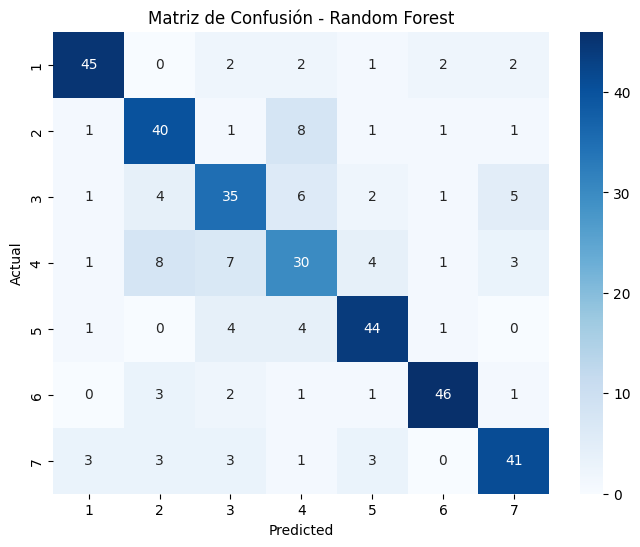


Entrenando modelo: Support Vector Machine


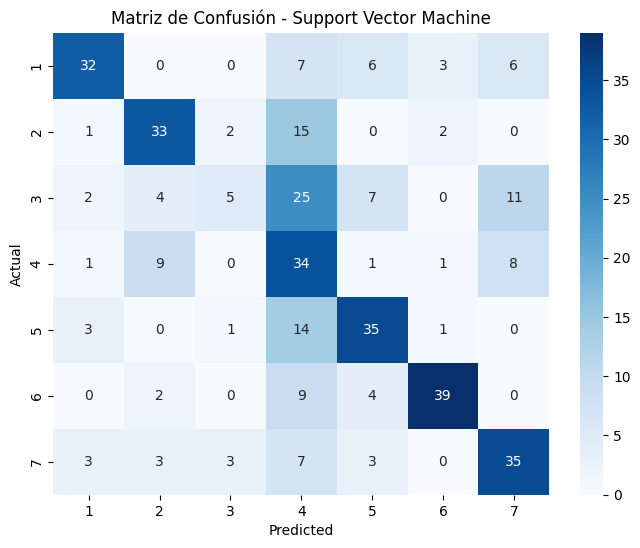


Entrenando modelo: Multilayer Perceptron


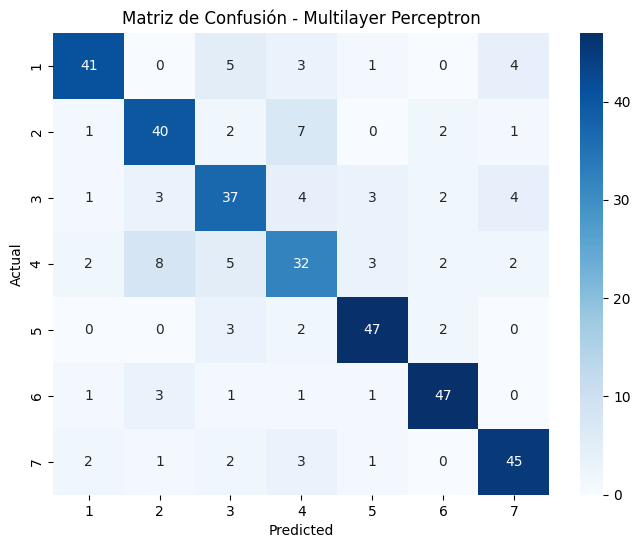


Resultados para Random Forest:
F1 Score: 0.7454 ± 0.4357
Accuracy: 0.7454 ± 0.4357
Precision: 0.7454 ± 0.4357
Recall: 0.7454 ± 0.4357
Tiempo de predicción total: 116.26 segundos

Resultados para Support Vector Machine:
F1 Score: 0.5650 ± 0.4958
Accuracy: 0.5650 ± 0.4958
Precision: 0.5650 ± 0.4958
Recall: 0.5650 ± 0.4958
Tiempo de predicción total: 8.75 segundos

Resultados para Multilayer Perceptron:
F1 Score: 0.7666 ± 0.4230
Accuracy: 0.7666 ± 0.4230
Precision: 0.7666 ± 0.4230
Recall: 0.7666 ± 0.4230
Tiempo de predicción total: 1659.65 segundos


In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Preparar X (características) e y (target)
X = df_pca.drop(columns=['Sujeto', 'Gesto', 'Repeticion']).values
y = df_pca['Gesto'].values

# Modelos a comparar
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(random_state=42),
    "Multilayer Perceptron": MLPClassifier(random_state=42,max_iter=5000)
}

# Inicializar Leave-One-Out Cross Validation
loo = LeaveOneOut()

# Diccionario para almacenar resultados
results = {model_name: {'f1': [], 'accuracy': [], 'precision': [], 'recall': [], 'time': []} for model_name in models.keys()}

# Iterar sobre cada modelo
for model_name, model in models.items():
    print(f"\nEntrenando modelo: {model_name}")
    start_time = time.time()

    # Inicializar matriz de confusión acumulada
    total_cm = np.zeros((len(np.unique(y)), len(np.unique(y))), dtype=int)

    # Leave-One-Out CV
    for train_index, test_index in loo.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        # Entrenar el modelo
        model.fit(X_train, y_train)

        # Predecir
        y_pred = model.predict(X_test)

        # Calcular métricas con `zero_division=0` para evitar mensajes de advertencia
        results[model_name]['f1'].append(f1_score(y_test, y_pred, average='weighted', zero_division=0))
        results[model_name]['accuracy'].append(accuracy_score(y_test, y_pred))
        results[model_name]['precision'].append(precision_score(y_test, y_pred, average='weighted', zero_division=0))
        results[model_name]['recall'].append(recall_score(y_test, y_pred, average='weighted', zero_division=0))

        # Actualizar matriz de confusión acumulada
        cm = confusion_matrix(y_test, y_pred, labels=np.unique(y))
        total_cm += cm

    # Tiempo total de predicción
    results[model_name]['time'] = time.time() - start_time

    # Mostrar matriz de confusión acumulada
    plt.figure(figsize=(8, 6))
    sns.heatmap(total_cm, annot=True, cmap='Blues', fmt='d', xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Matriz de Confusión - {model_name}')
    plt.show()

# Mostrar resultados finales
for model_name, metrics in results.items():
    print(f"\nResultados para {model_name}:")
    print(f"F1 Score: {np.mean(metrics['f1']):.4f} ± {np.std(metrics['f1']):.4f}")
    print(f"Accuracy: {np.mean(metrics['accuracy']):.4f} ± {np.std(metrics['accuracy']):.4f}")
    print(f"Precision: {np.mean(metrics['precision']):.4f} ± {np.std(metrics['precision']):.4f}")
    print(f"Recall: {np.mean(metrics['recall']):.4f} ± {np.std(metrics['recall']):.4f}")
    print(f"Tiempo de predicción total: {metrics['time']:.2f} segundos")



Entrenando modelos con normalización: RobustScaler

Entrenando modelo: Random Forest (RobustScaler)


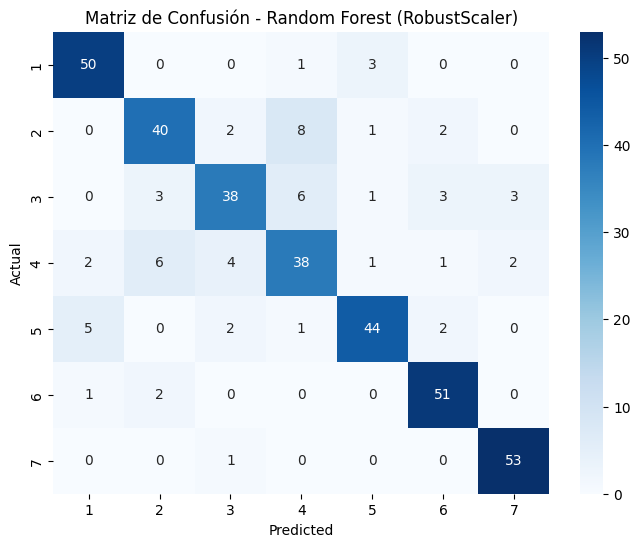


Entrenando modelo: Support Vector Machine (RobustScaler)


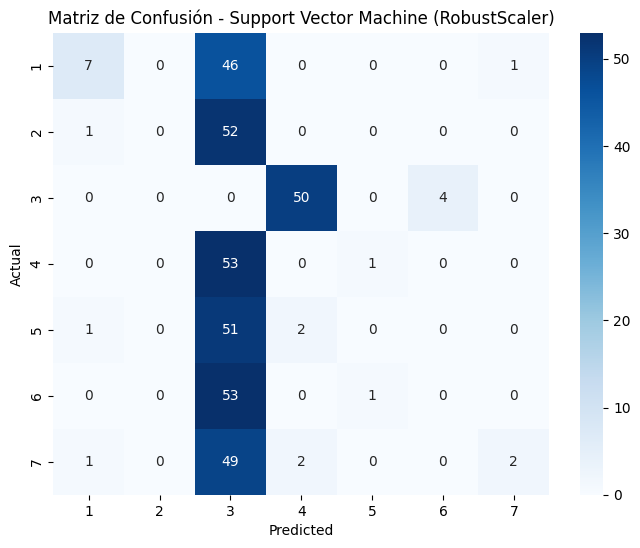


Entrenando modelo: Multilayer Perceptron (RobustScaler)


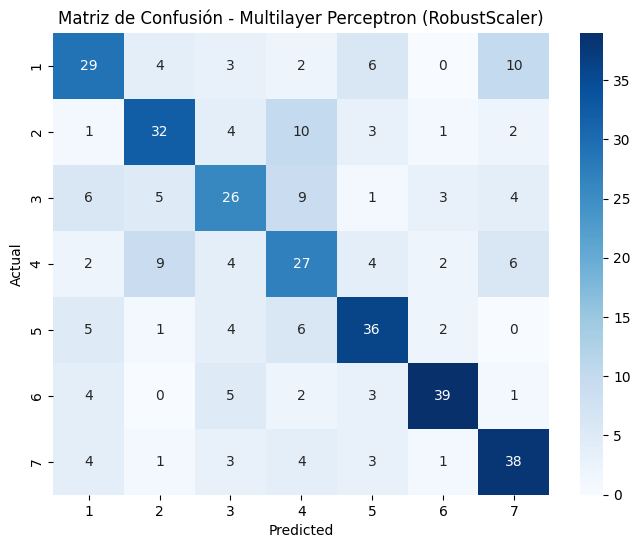


Resultados para Random Forest (RobustScaler):
F1 Score: 0.8329 ± 0.3731
Accuracy: 0.8329 ± 0.3731
Precision: 0.8329 ± 0.3731
Recall: 0.8329 ± 0.3731
Tiempo de predicción total: 161.66 segundos

Resultados para Support Vector Machine (RobustScaler):
F1 Score: 0.0239 ± 0.1527
Accuracy: 0.0239 ± 0.1527
Precision: 0.0239 ± 0.1527
Recall: 0.0239 ± 0.1527
Tiempo de predicción total: 10.95 segundos

Resultados para Multilayer Perceptron (RobustScaler):
F1 Score: 0.6021 ± 0.4895
Accuracy: 0.6021 ± 0.4895
Precision: 0.6021 ± 0.4895
Recall: 0.6021 ± 0.4895
Tiempo de predicción total: 731.64 segundos

Entrenando modelos con normalización: StandardScaler

Entrenando modelo: Random Forest (StandardScaler)


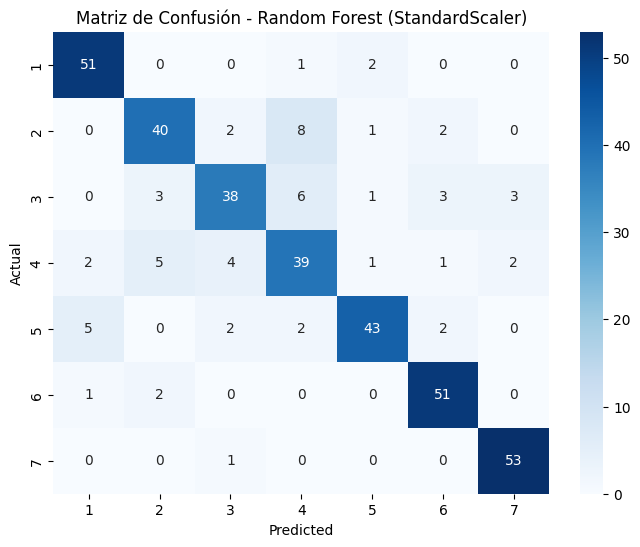


Entrenando modelo: Support Vector Machine (StandardScaler)


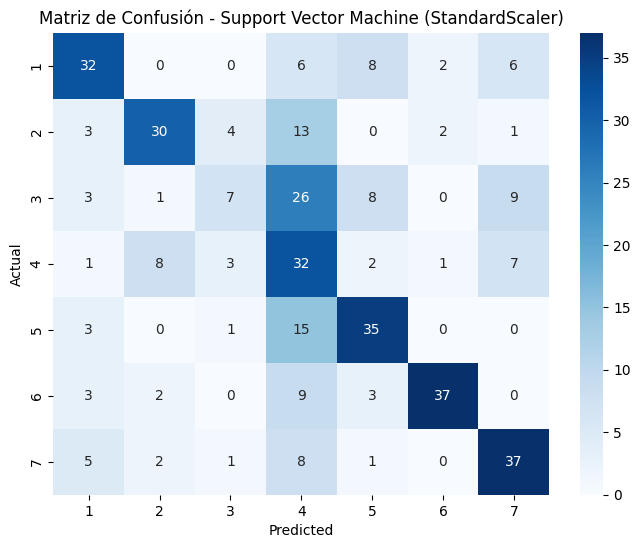


Entrenando modelo: Multilayer Perceptron (StandardScaler)


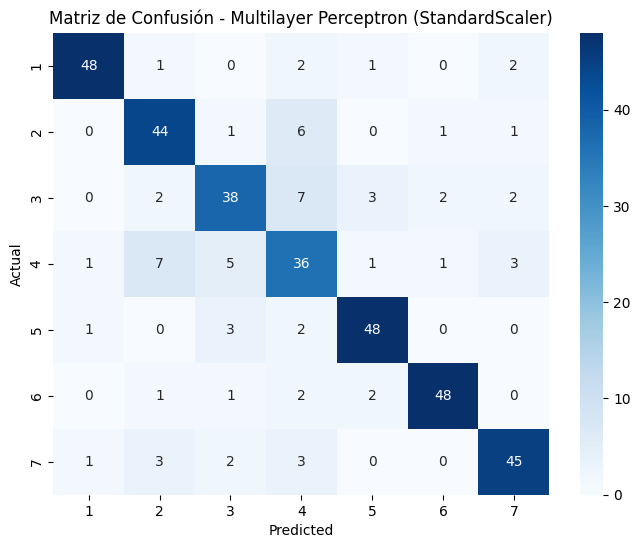


Resultados para Random Forest (StandardScaler):
F1 Score: 0.8355 ± 0.3707
Accuracy: 0.8355 ± 0.3707
Precision: 0.8355 ± 0.3707
Recall: 0.8355 ± 0.3707
Tiempo de predicción total: 163.39 segundos

Resultados para Support Vector Machine (StandardScaler):
F1 Score: 0.5570 ± 0.4967
Accuracy: 0.5570 ± 0.4967
Precision: 0.5570 ± 0.4967
Recall: 0.5570 ± 0.4967
Tiempo de predicción total: 8.92 segundos

Resultados para Multilayer Perceptron (StandardScaler):
F1 Score: 0.8143 ± 0.3888
Accuracy: 0.8143 ± 0.3888
Precision: 0.8143 ± 0.3888
Recall: 0.8143 ± 0.3888
Tiempo de predicción total: 1293.83 segundos


In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Preparar X (características) e y (target) para las dos normalizaciones
datasets = {
    "RobustScaler": robust_scaled_df,
    "StandardScaler": standard_scaled_df
}

# Modelos a comparar
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(random_state=42),
    "Multilayer Perceptron": MLPClassifier(random_state=42,max_iter=5000)
}

# Resultados para ambas normalizaciones
results_summary = {}

# Iterar sobre cada normalización
for norm_name, scaled_df in datasets.items():
    print(f"\nEntrenando modelos con normalización: {norm_name}")
    results_summary[norm_name] = {}

    # Separar características y target
    X = scaled_df.drop(columns=['Sujeto', 'Gesto', 'Repeticion']).values
    y = scaled_df['Gesto'].values

    # Inicializar Leave-One-Out Cross Validation
    loo = LeaveOneOut()

    # Diccionario para almacenar resultados
    results = {model_name: {'f1': [], 'accuracy': [], 'precision': [], 'recall': [], 'time': []} for model_name in models.keys()}

    # Iterar sobre cada modelo
    for model_name, model in models.items():
        print(f"\nEntrenando modelo: {model_name} ({norm_name})")
        start_time = time.time()

        # Inicializar matriz de confusión acumulada
        total_cm = np.zeros((len(np.unique(y)), len(np.unique(y))), dtype=int)

        # Leave-One-Out CV
        for train_index, test_index in loo.split(X):
            X_train, X_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]

            # Entrenar el modelo
            model.fit(X_train, y_train)

            # Predecir
            y_pred = model.predict(X_test)

            # Calcular métricas con `zero_division=0` para evitar mensajes de advertencia
            results[model_name]['f1'].append(f1_score(y_test, y_pred, average='weighted', zero_division=0))
            results[model_name]['accuracy'].append(accuracy_score(y_test, y_pred))
            results[model_name]['precision'].append(precision_score(y_test, y_pred, average='weighted', zero_division=0))
            results[model_name]['recall'].append(recall_score(y_test, y_pred, average='weighted', zero_division=0))

            # Actualizar matriz de confusión acumulada
            cm = confusion_matrix(y_test, y_pred, labels=np.unique(y))
            total_cm += cm

        # Tiempo total de predicción
        results[model_name]['time'] = time.time() - start_time

        # Mostrar matriz de confusión acumulada
        plt.figure(figsize=(8, 6))
        sns.heatmap(total_cm, annot=True, cmap='Blues', fmt='d', xticklabels=np.unique(y), yticklabels=np.unique(y))
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title(f'Matriz de Confusión - {model_name} ({norm_name})')
        plt.show()

    # Resumen de resultados
    for model_name, metrics in results.items():
        print(f"\nResultados para {model_name} ({norm_name}):")
        print(f"F1 Score: {np.mean(metrics['f1']):.4f} ± {np.std(metrics['f1']):.4f}")
        print(f"Accuracy: {np.mean(metrics['accuracy']):.4f} ± {np.std(metrics['accuracy']):.4f}")
        print(f"Precision: {np.mean(metrics['precision']):.4f} ± {np.std(metrics['precision']):.4f}")
        print(f"Recall: {np.mean(metrics['recall']):.4f} ± {np.std(metrics['recall']):.4f}")
        print(f"Tiempo de predicción total: {metrics['time']:.2f} segundos")

    # Guardar los resultados para esta normalización
    results_summary[norm_name] = results
